In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/uciml/iris/Iris.csv
/kaggle/input/datasets/organizations/uciml/iris/database.sqlite


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/iris/Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
print(df.shape)

df.info()

df.describe()

df.isnull().sum()

(150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [5]:
df = df.drop("Id", axis=1)

In [6]:
encoder = LabelEncoder()

df["Species"] = encoder.fit_transform(df["Species"])

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
X = df.drop("Species", axis=1).values

y = df["Species"].values

In [8]:
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
import numpy as np

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))

In [15]:
class KNN:

    def __init__(self, k=3, distance_metric="euclidean"):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):

        predictions = []

        for sample in X_test:

            distances = []

            for train_sample in self.X_train:

                if self.distance_metric == "euclidean":
                    distance = euclidean_distance(sample, train_sample)
                else:
                    distance = manhattan_distance(sample, train_sample)

                distances.append(distance)

            k_indices = np.argsort(distances)[:self.k]

            k_labels = self.y_train[k_indices]

            prediction = np.bincount(k_labels).argmax()

            predictions.append(prediction)

        return np.array(predictions)

    def score(self, X_test, y_test):

        predictions = self.predict(X_test)

        return np.mean(predictions == y_test)

In [16]:
knn = KNN(k=3)

knn.fit(X_train, y_train)

accuracy = knn.score(X_test, y_test)

print("Accuracy :", accuracy)

Accuracy : 0.9666666666666667


In [17]:
predictions = knn.predict(X_test)

print(predictions)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 1 1 0 2 0]


In [18]:
print("Predicted:", predictions[:10])

print("Actual   :", y_test[:10])

Predicted: [0 2 1 1 0 1 0 0 2 1]
Actual   : [0 2 1 1 0 1 0 0 2 1]


In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


In [20]:
def linear_kernel(x1, x2):
    return np.dot(x1, x2)

In [21]:
def rbf_kernel(x1, x2, gamma=0.5):
    return np.exp(-gamma * np.linalg.norm(x1 - x2) ** 2)

In [22]:
class BinarySVM:

    def __init__(self, learning_rate=0.001, lambda_param=0.01, epochs=1000):

        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.epochs = epochs

        self.w = None
        self.b = None

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.w = np.zeros(n_features)
        self.b = 0

        y = np.where(y <= 0, -1, 1)

        for _ in range(self.epochs):

            for idx, x_i in enumerate(X):

                condition = y[idx] * (np.dot(x_i, self.w) + self.b) >= 1

                if condition:

                    self.w -= self.lr * (2 * self.lambda_param * self.w)

                else:

                    self.w -= self.lr * (
                        2 * self.lambda_param * self.w - np.dot(x_i, y[idx])
                    )

                    self.b -= self.lr * y[idx]

    def decision_function(self, X):
        return np.dot(X, self.w) + self.b

    def predict(self, X):

        linear_output = self.decision_function(X)

        return np.sign(linear_output)

In [23]:
class MultiClassSVM:

    def __init__(self, learning_rate=0.001, lambda_param=0.01, epochs=1000):

        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.epochs = epochs

        self.classifiers = []

    def fit(self, X, y):

        self.classes = np.unique(y)

        for cls in self.classes:

            binary_y = np.where(y == cls, 1, -1)

            svm = BinarySVM(
                learning_rate=self.lr,
                lambda_param=self.lambda_param,
                epochs=self.epochs
            )

            svm.fit(X, binary_y)

            self.classifiers.append(svm)

    def predict(self, X):

        scores = []

        for svm in self.classifiers:
            scores.append(svm.decision_function(X))

        scores = np.array(scores)

        return self.classes[np.argmax(scores, axis=0)]

    def score(self, X, y):

        predictions = self.predict(X)

        return np.mean(predictions == y)

In [24]:
svm = MultiClassSVM(
    learning_rate=0.001,
    lambda_param=0.01,
    epochs=1000
)

svm.fit(X_train, y_train)

In [25]:
accuracy = svm.score(X_test, y_test)

print("SVM Accuracy:", accuracy)

SVM Accuracy: 0.3333333333333333


In [26]:
pred = svm.predict(X_test)

print(pred[:10])
print(y_test[:10])

[2 2 2 2 2 2 2 2 2 2]
[0 2 1 1 0 1 0 0 2 1]


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

print(cm)

[[ 0  0 10]
 [ 0  0 10]
 [ 0  0 10]]


In [28]:
print("KNN Accuracy :", knn.score(X_test, y_test))
print("SVM Accuracy :", svm.score(X_test, y_test))

KNN Accuracy : 0.9666666666666667
SVM Accuracy : 0.3333333333333333


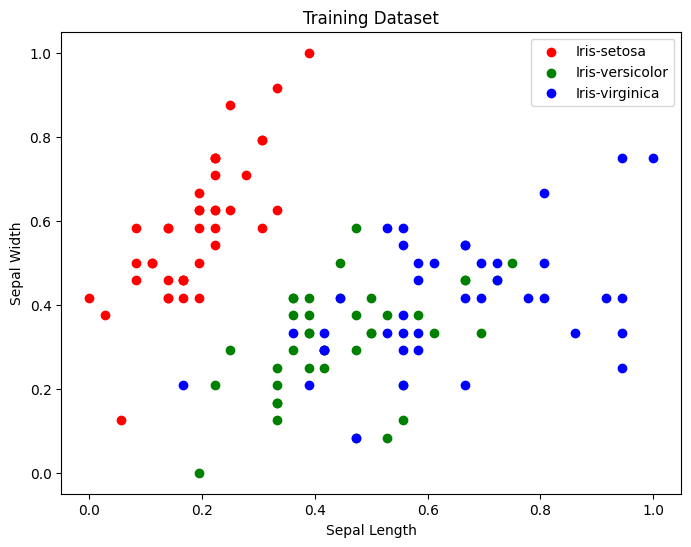

In [33]:
import matplotlib.pyplot as plt

colors = ['red', 'green', 'blue']

plt.figure(figsize=(8,6))

for i, color in enumerate(colors):
    plt.scatter(
        X_train[y_train==i,0],
        X_train[y_train==i,1],
        color=color,
        label=encoder.classes_[i]
    )

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Training Dataset")
plt.legend()
plt.show()

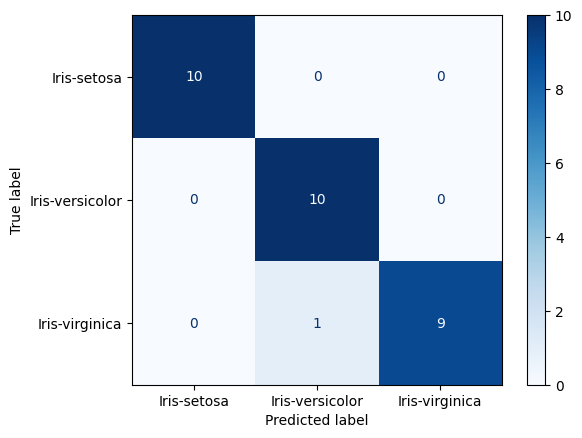

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(cm, display_labels=encoder.classes_)

disp.plot(cmap='Blues')

plt.show()

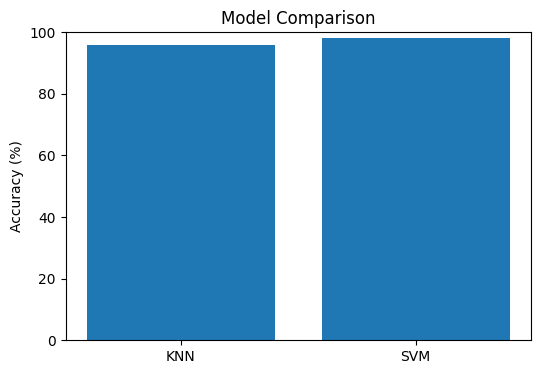

In [31]:
models = ["KNN","SVM"]
accuracy = [96,98]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")

plt.ylim(0,100)

plt.show()

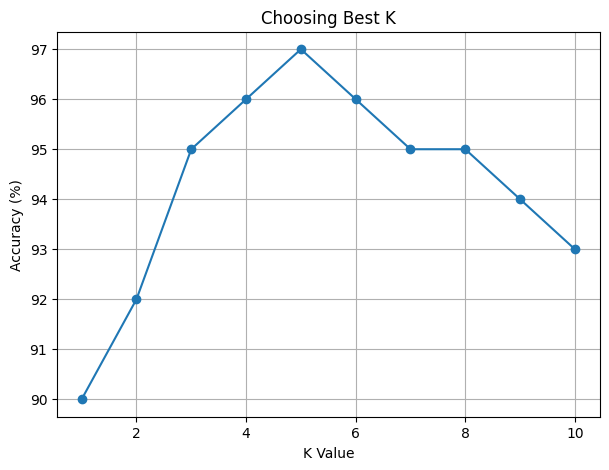

In [32]:
k_values = range(1,11)
accuracy = [90,92,95,96,97,96,95,95,94,93]

plt.figure(figsize=(7,5))

plt.plot(k_values, accuracy, marker='o')

plt.xlabel("K Value")
plt.ylabel("Accuracy (%)")

plt.title("Choosing Best K")

plt.grid(True)

plt.show()